# Introduction to DEA Fuel Moisture Content <img align="right" src="https://github.com/GeoscienceAustralia/dea-notebooks/raw/develop/Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with the `DEA Sandbox` environment only
* **Products used:** [ga_s2_fmc_3_v1](https://explorer.dea.ga.gov.au/products/ga_s2_fmc_3_v1)

## Background
Australia’s hot, dry climate and vast bushland make it one of the most fire-prone regions on Earth. Understanding vegetation dryness is critical for managing bushfire risk.

One key measure used for this purpose is Fuel Moisture Content (FMC) which refers to the amount of water contained in vegetation, expressed as a percentage of its dry weight. FMC plays a vital role in fire management because it indicates how easily vegetation can ignite and sustain fire; lower FMC levels mean drier and more flammable fuel. Digital Earth Australia (DEA) FMC is a remotely sensed proxy of FMC.

### What this product offers
DEA Fuel Moisture Content (FMC) product is a remotely sensed proxy for the moisture content of vegetation. It estimates the percentage of water mass relative to dry mass in living vegetation based on its spectral signature. Vegetation moisture is a critical variable for understanding vegetation flammability and fire potential.

Values range from 0 – 300%, representing by weight percent the amount of water in leaves compared to dry plant material. A value of 0% would indicate that there is no water content. A value of 100% indicates there is an equal weight of water and dry plant material. A value of 300% would mean there is approximately three times as much water as dry plant material. Values in the range of 0 – 150% are particularly relevant to fire behaviour analysis, as this range is strongly associated with changes in vegetation flammability and the likelihood of ignition.

DEA FMC is derived from [Sentinel-2 NBART](https://knowledge.dea.ga.gov.au/notebooks/DEA_products/DEA_Sentinel2_Surface_Reflectance/) satellite imagery at a 20 m resolution for all of Australia from 12 July 2015 to the present. It provides pixel-level FMC values for each corresponding Sentinel-2 scene, with masking applied to exclude clouds, cloud shadows, water, and terrain shadows.

### Applications
* Monitoring and mapping the dryness of vegetation across different landscapes.
* Predicting and assessing vegetation flammability and fire risk, including fire spread and intensity.
* Modelling fire risk over time and across different ecosystems with changing climate conditions.
* Prioritising and evaluating fire, forestry, and utility agency management based on the dryness and assessed fire risk of vegetation.

**Please note that this product should not be used to make safety of life decisions.**

### Publications
Remotely sensed FMC was developed by Dr. Marta Yebra at the Australian National University (ANU). DEA FMC is a collaboration between the ANU and Geoscience Australia to operationalise Sentinel-2 based fuel moisture content. 

* Yebra, M., Quan, X., Riaño, D., Rozas Larraondo, P., van Dijk, A. I. J. M., & Cary, G. J., 2018. A fuel moisture content and flammability monitoring methodology for continental Australia based on optical remote sensing. *Remote Sensing of Environment*, 212, 260–272. https://doi.org/10.1016/j.rse.2018.04.053

## Description

This notebook will demonstrate how to load data from the DEA Fuel Moisture Content product using the Digital Earth Australia datacube. 
Topics covered include:

1. Inspecting the products and measurements available in the datacube.
2. Loading DEA Fuel Moisture Content data for an area of interest.
3. Plotting DEA Fuel Moisture Content data.

<div class="alert alert-info">
    
**Note:** Visit the [DEA Fuel Moisture Content product documentation](https://knowledge.dea.ga.gov.au/data/product/dea-fuel-moisture-content/) for detailed technical information including methods, quality, and data access.
To explore DEA Fuel Moisture Content on an interactive map, [visit DEA Maps](https://maps.dea.ga.gov.au/).

</div>

***


## Getting started

To run this analysis, run all the cells in the notebook starting with the 'Load packages' cell. 

### Load packages
Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import sys
import datacube
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from datacube.utils.masking import mask_invalid_data

sys.path.insert(1, "../Tools/")
from dea_tools.plotting import display_map

### Connect to the datacube

Connect to the datacube so we can access DEA data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app="DEA_Fuel_Moisture_Content")

## Select and view your area of interest

**If running the notebook for the first time,** keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.

The following example loads Fuel Moisture Content data for the Wiarborough Nature Reserve and surrounding areas in New South Wales.

This example uses coordinates to select your area of interest. If you prefer, you may use a polygon to specify the area instead – see the [Polygon drill](https://knowledge.dea.ga.gov.au/notebooks/How_to_guides/Polygon_drill/) guide for steps on how to use a vector file for your area of interest.

In [3]:
# Coordinates for Wiarborough Nature Reserve and surrounds
lat = -34.1987
lon = 149.8405
lat_buffer = 0.04
lon_buffer = 0.05

# Combine central coordinates with buffer values to create the latitude and longitude range for the analysis
lat_range = (lat - lat_buffer, lat + lat_buffer)
lon_range = (lon - lon_buffer, lon + lon_buffer)

The following cell will display the selected area on an interactive map.
You can zoom in and out to better understand the area you'll be analysing. 
Clicking on any point on the map will reveal that point's latitude and longitude coordinates.

In [4]:
display_map(x=lon_range, y=lat_range)

## Available products and measurements
We can use datacube’s `list_products()` function to inspect the DEA Fuel Moisture Content (FMC) product that is available in Digital Earth Australia. Fuel Moisture Content has been produced for Sentinel-2.

The table below shows the product name that we will use to load data, and a brief description of the product.

In [5]:
# List DEA FMC products available in DEA
pd.set_option('display.max_colwidth', None)
dc_products = dc.list_products()
dc_products.loc[['ga_s2_fmc_3_v1']]

,name,description,license,default_crs,default_resolution
name,,,,,
ga_s2_fmc_3_v1,ga_s2_fmc_3_v1,Geoscience Australia Sentinel MSI Fuel Moisture Content Collection 3,CC-BY-4.0,EPSG:3577,"(-20, 20)"


We can also inspect the contents of the DEA Fuel Moisture Content (FMC) product using datacube’s `list_measurements()` function. DEA Fuel Moisture Content only has one measurement, `fmc`, as seen in the table below. This is the calculated fuel moisture content.

In [6]:
dc_measurements = dc.list_measurements()
dc_measurements.loc[['ga_s2_fmc_3_v1']]

,,name,dtype,units,nodata,aliases,flags_definition
product,measurement,,,,,,
ga_s2_fmc_3_v1,fmc,fmc,int16,1,-999,NaN,NaN


## Load and view DEA Fuel Moisture Content data 
The following cell will load data for the `lat_range` and `lon_range` we defined above.
We can do this using the `dc.load()` function to load the DEA FMC product. All parameters in the query can be adapted to suit your interest.

> **Note:** DEA Fuel Moisture Content has only one band, therefore, the following cell does not specify a measurement parameter.

In [7]:
# Create the 'query' dictionary object, which contains the longitudes and latitudes defined above, as well as other important parameters.
query = {
    "y": lat_range,
    "x": lon_range,
    "time": ("2021-01-01", "2021-12-31"),
    "output_crs": "EPSG:3577",
    "resolution": (-20, 20),
    "group_by": "solar_day"
}

# Load DEA FMC product from the datacube
ds = dc.load(
    product=["ga_s2_fmc_3_v1"],
    **query
)

ds

<xarray.Dataset> Size: 37MB
Dimensions:      (time: 71, y: 506, x: 517)
Coordinates:
  * time         (time) datetime64[ns] 568B 2021-01-04T00:06:12.180338 ... 20...
  * y            (y) float64 4kB -3.842e+06 -3.842e+06 ... -3.852e+06 -3.852e+06
  * x            (x) float64 4kB 1.626e+06 1.626e+06 ... 1.636e+06 1.636e+06
    spatial_ref  int32 4B 3577
Data variables:
    fmc          (time, y, x) int16 37MB -999 -999 -999 -999 ... 73 61 53 65
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## Plotting data
The following section will show you how to plot DEA Fuel Moisture Content data using the `.plot()` function.

First, use `LinearSegmentedColormap` to set a predefined colour map to best visualise the Fuel Moisture Content values.

In [8]:
# Define colour map for plotting 
colours = [(0.808, 0.0, 0.128), (1, 1, 0.73), (0.176, 0.492, 0.728)]
cmap = LinearSegmentedColormap.from_list('fmc', colours, N=256)

Then, use the cell below to mask out the `nodata` pixels which are represented by value `-999`. The `nodata` pixels are those of cloud, terrain shadow and water.

In [9]:
ds = mask_invalid_data(ds)

Lastly, plot the masked and loaded DEA Fuel Moisture Content data using the colour map specified above. The `.isel()` function is used to select the last time step in the loaded data range.

> **Note:** FMC values range from 0% to 300 %. This FMC example is displayed with a colour stretch that highlights changes between the values of 0 % and 150 %. This is because changes to values within this range are of most interest for the purposes of understanding flammability.

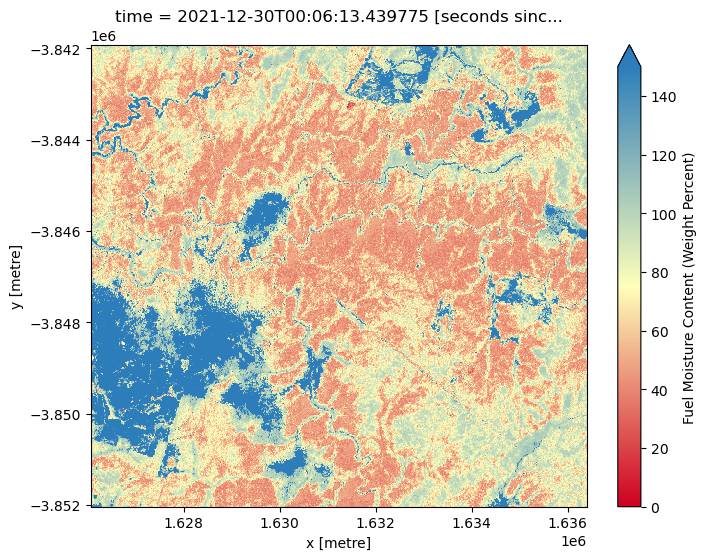

In [10]:
# Plot the masked data for the first time step
fmc_plot = ds.fmc.isel(time=-1).plot(cmap=cmap, vmin=0, vmax=150, size=6)

fmc_plot.colorbar.set_label('Fuel Moisture Content (Weight Percent)');

**Vegetation moisture is a critical variable for understanding vegetation flammability and fire potential, as lower FMC levels indicate drier, more flammable fuel.**

Using the loaded data, we can compare the FMC values of the Wiarborough Nature Reserve and the surrounding areas in context of the Australian fire season. 
In New South Wales, the fire season is from the start of October to the end of March. 

Using the `.subplots()` function, the pre-fire season and middle of fire season FMC values are visualised for 2021. The FMC values in December are much lower, indicating the vegetation flammability is higher in this time period.

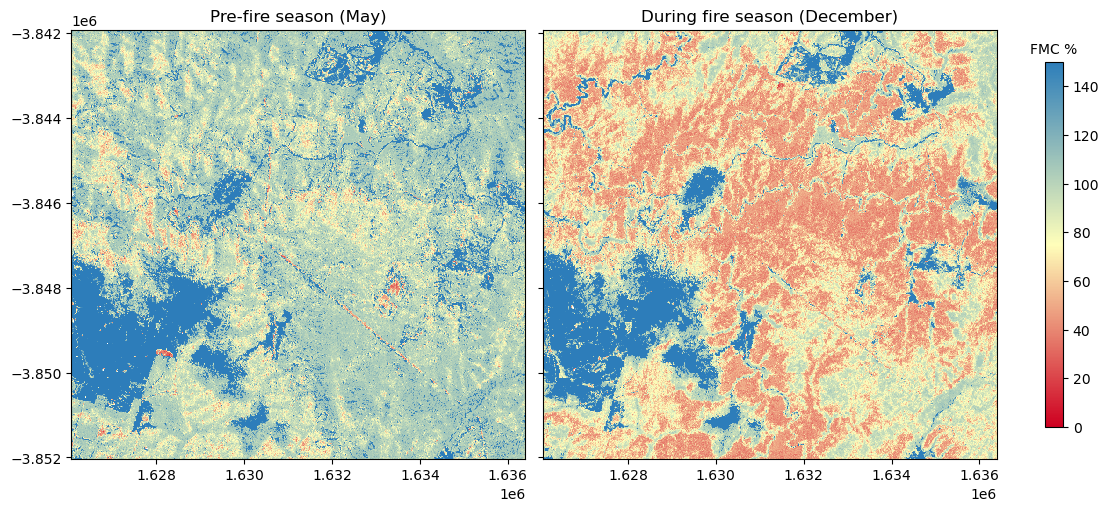

In [11]:
# Create subplots to visualise pre-fire and during fire season FMC values
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharey=True, layout="constrained")

vmin, vmax = 0, 150

pre_fire_season = ds.fmc.isel(time=19).plot(
    ax=ax[0], cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False, add_labels=False
)
im = fire_season = ds.fmc.isel(time=-1).plot(
    ax=ax[1], cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False, add_labels=False
)

cb = fig.colorbar(im, ax=ax, shrink=0.85, orientation="vertical")
cb.ax.set_title("FMC %", fontsize=10)
ax[0].set_title("Pre-fire season (May)")
ax[1].set_title("During fire season (December)");

## Plotting a time series
The following section will show you how to how to calculate and plot a monthly time series chart of the DEA Fuel Moisture Content data.

From the loaded `xarray` `Dataset` (`ds`), we need to select the FMC data variable, `"fmc"`. Next, we calculate the average FMC value across all spatial pixels for each time step using `.mean(['x', 'y'])`.

In [12]:
fmc_da_mean = ds["fmc"].mean(['x', 'y'])
fmc_da_mean

<xarray.DataArray 'fmc' (time: 71)> Size: 284B
array([       nan,  81.55094 ,  69.02075 ,  80.82179 ,  68.940956,
              nan,  83.73061 , 102.195244, 118.28273 , 117.07408 ,
        92.15023 ,  97.739845, 113.012695, 109.34617 ,        nan,
              nan, 112.1722  , 104.07567 ,        nan, 112.48486 ,
       111.20388 , 118.028145, 119.071045,        nan,        nan,
       111.8666  , 110.49558 , 115.01035 , 112.33938 ,        nan,
       114.28026 , 101.1337  ,  90.52689 ,        nan, 121.64618 ,
        90.25559 , 127.68957 , 120.11781 , 102.737854,  87.120964,
       114.63927 , 114.09124 , 107.15066 , 118.45351 , 112.75705 ,
        96.466324, 107.5998  ,  91.50768 , 101.83336 ,  86.125275,
        93.60287 , 118.15257 ,  99.27116 , 130.77484 ,  79.0856  ,
              nan,  88.07692 , 106.79427 ,  77.59385 ,  80.87102 ,
              nan, 107.32992 ,        nan,        nan,  83.98391 ,
        98.41297 , 101.21792 ,  72.408485,  84.72193 ,  79.26805 ,
        83.47715 ], dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 568B 2021-01-04T00:06:12.180338 ... 20...
    spatial_ref  int32 4B 3577

Then, we will resample the datasets to monthly means to remove any noise or missing data from individual time steps and calculate the mean for each month. This will give us a clean, monthly time series.

In [13]:
monthly_mean = fmc_da_mean.resample(time='MS').mean('time')

Lastly, using `.plot()` we can visualise the average FMC value per month in 2021 for the Wiarborough Nature Reserve and surrounds. The end of the fire season (April) has the wettest vegetation, while the driest vegetation is seen during the fire season, in particular December and January. 

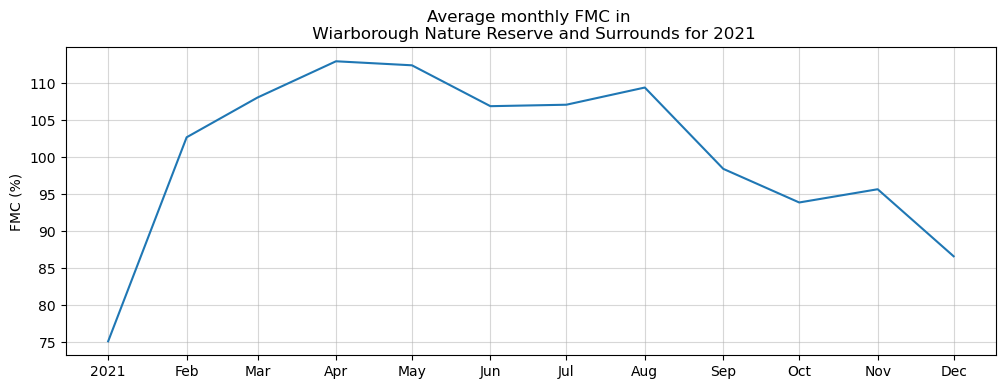

In [14]:
fig, ax = plt.subplots(figsize=(12, 4))

monthly_mean.plot(ax=ax)
ax.set(
    xlabel=None,
    ylabel="FMC (%)",
    title="Average monthly FMC in \n Wiarborough Nature Reserve and Surrounds for 2021",
)

ax.set_xticks(monthly_mean.time.values)
ax.grid(alpha=0.5);

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** October 2025

**Compatible datacube version:** 

In [15]:
print(datacube.__version__)

1.8.19


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->